# Exploratory Data Analysis (EDA) on IoT Dataset

**Name:** Ananya Thakur  
**Reg. No.:** RA2311033010025  
**Branch:** B.Tech CSE w/s SOFTWARE ENGINEERING  
**Section:** AI2  

**Goal:** Perform EDA using visualizations and statistics to understand patterns, trends, and key insights from the dataset.  

In [1]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("iot_synthetic.csv")
df.head()

,timestamp,device,packet_rate,byte_rate,conn_count,tcp_syn,udp_ratio,label
0,2024-01-01 09:00:00,webcam,6.031,4388.8,4,2,0.125,benign
1,2024-01-01 09:00:05,baby_monitor,6.197,6197.1,2,1,0.405,benign
2,2024-01-01 09:00:10,thermostat,13.863,3235.0,1,0,0.323,benign
3,2024-01-01 09:00:15,webcam,6.276,4846.8,3,3,0.328,benign
4,2024-01-01 09:00:20,doorbell,9.241,6484.9,5,1,0.576,benign


In [2]:
# Correlation analysis
print("Correlation Matrix:")
print(df.corr(numeric_only=True))

Correlation Matrix:
             packet_rate  byte_rate  conn_count   tcp_syn  udp_ratio
packet_rate     1.000000   0.569649    0.389572  0.030233   0.506429
byte_rate       0.569649   1.000000    0.420259 -0.004177   0.543030
conn_count      0.389572   0.420259    1.000000  0.354016   0.376008
tcp_syn         0.030233  -0.004177    0.354016  1.000000   0.022019
udp_ratio       0.506429   0.543030    0.376008  0.022019   1.000000


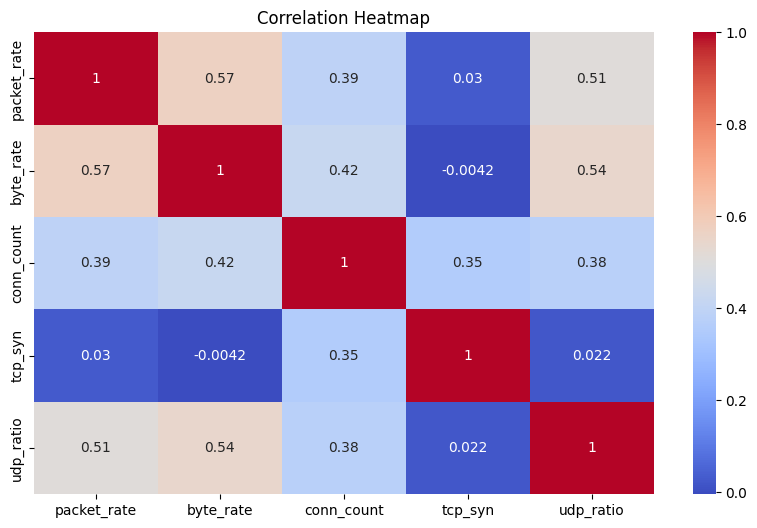

In [3]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

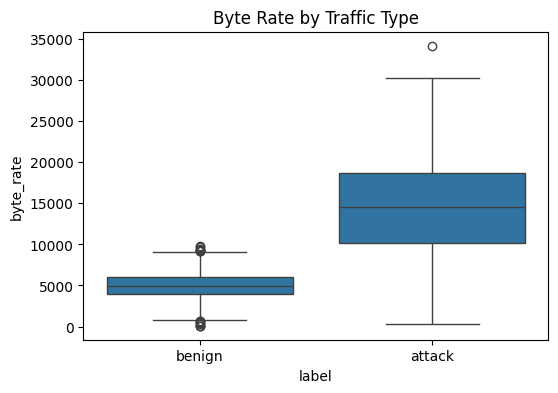

In [4]:
# Boxplot for byte_rate grouped by label
plt.figure(figsize=(6,4))
sns.boxplot(x="label", y="byte_rate", data=df)
plt.title("Byte Rate by Traffic Type")
plt.show()

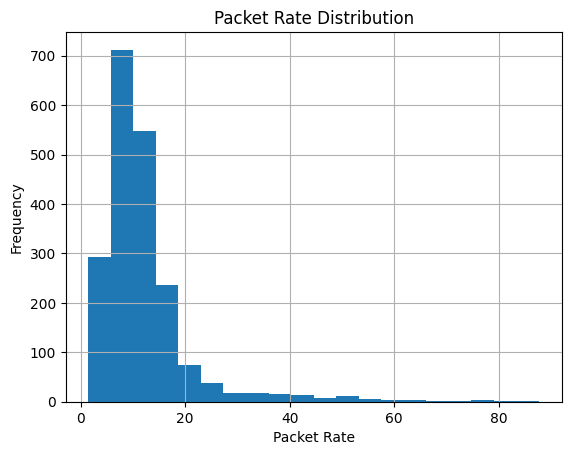

In [5]:
# Histogram for packet_rate
df["packet_rate"].hist(bins=20)
plt.xlabel("Packet Rate")
plt.ylabel("Frequency")
plt.title("Packet Rate Distribution")
plt.show()

In [6]:
# Probability distribution of device types
device_prob = df["device"].value_counts(normalize=True)
print("Probability distribution of devices:")
print(device_prob)

Probability distribution of devices:
device
doorbell        0.3525
webcam          0.2980
thermostat      0.1970
baby_monitor    0.1525
Name: proportion, dtype: float64


In [7]:
# Conditional probability: P(Attack | Device)
for dev in df["device"].unique():
    p_attack_given_dev = (df[df["device"]==dev]["label"]=="attack").mean()
    print(f"Probability of attack given {dev}: {p_attack_given_dev:.2f}")

Probability of attack given webcam: 0.08
Probability of attack given baby_monitor: 0.10
Probability of attack given thermostat: 0.07
Probability of attack given doorbell: 0.07


In [8]:
# Joint probability example: P(Device=doorbell AND Attack)
joint_prob = ((df["device"]=="doorbell") & (df["label"]=="attack")).mean()
print(f"Joint probability of doorbell device being under attack: {joint_prob:.2f}")

Joint probability of doorbell device being under attack: 0.03


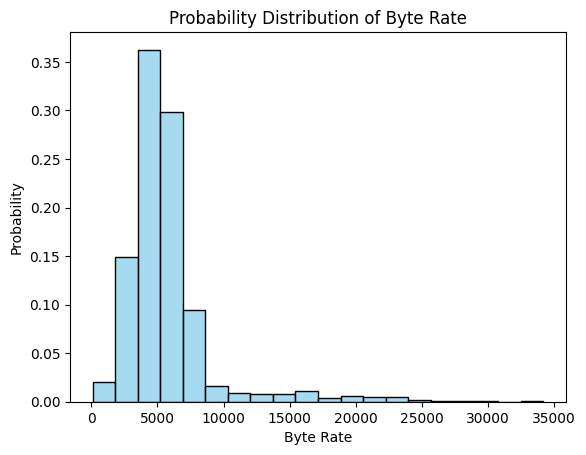

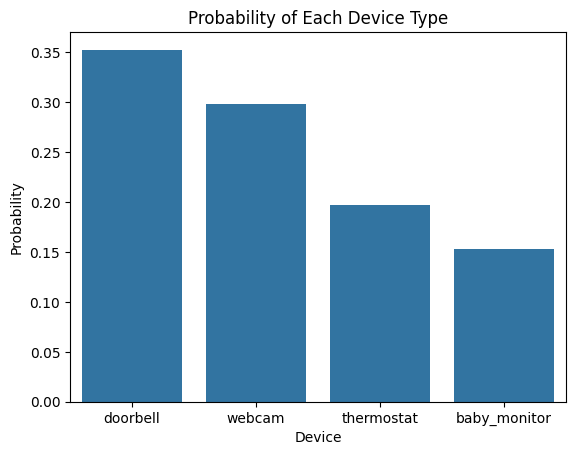

In [9]:
# Probability distribution plots

# Histogram (Byte Rate Distribution)
sns.histplot(df["byte_rate"], stat="probability", bins=20, color="skyblue")
plt.title("Probability Distribution of Byte Rate")
plt.xlabel("Byte Rate")
plt.ylabel("Probability")
plt.show()

# Barplot (Device Type Probability)
sns.barplot(x=device_prob.index, y=device_prob.values)
plt.title("Probability of Each Device Type")
plt.xlabel("Device")
plt.ylabel("Probability")
plt.show()

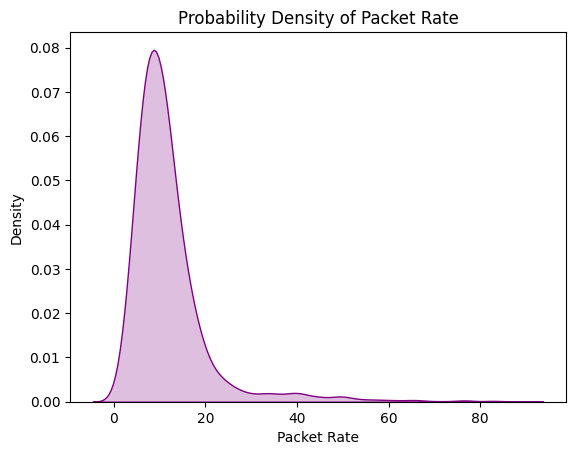

In [10]:
# KDE plot for packet_rate
sns.kdeplot(df["packet_rate"], fill=True, color="purple")
plt.title("Probability Density of Packet Rate")
plt.xlabel("Packet Rate")
plt.show()